# Modelling
In this notebook, we will test out various models on the dataset with SMOTENC and k-Nearest Neighbors imputation

Before modelling, the numerical data will be scaled using the MinMaxScaler because these features operate on different units, and have important outliers.

In [30]:
# Import libraries
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv('../data/smotenc_knn_df.csv') # k-Nearest Neighbors imputed dataset with SMOTENC

In [31]:
# Import train, test, split
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns='TenYearCHD')
y = df['TenYearCHD']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Storing models in a dictionary for ease of access

In [32]:
# Import libraries
from sklearn.linear_model import LogisticRegression # Scale sensitive
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB # Scale insensitive
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier


# Dictionary of scale insensitive models
scale_ins_models = {
    'Naive-Bayes': GaussianNB(),
    'Gradient Boosting' : GradientBoostingClassifier(),
    'Random Forest' : RandomForestClassifier(random_state=42)
}

# Dictionary of scale sensitive models
scale_sens_models = {
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'SVC' : SVC(random_state=42)
}

In order to determine which model performs the best, we will define a function that allows us to assess model performance using AUC-ROC as a metric, and stratified k-fold as a technique.

In [33]:
# Import Libraries
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define a function to evaluate model performance
def model_eval(model, X, y):
    # Apply k-fold cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    
    # Print performance metrics
    print(f'Mean Cross-Validation ROC-AUC: {scores.mean():.2f} +- {scores.std():.3f}')

In [34]:
# Import libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# List of continuous features
cont_features = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose' ,'MAP']

# Scale the continuous data
#scaler = MinMaxScaler()
#X_train[cont_features] = scaler.fit_transform(X_train[cont_features])
#X_test[cont_features] = scaler.fit_transform(X_test[cont_features])

# Scale Insensitive Models

--Evaluating Naive-Bayes--
Cross-Validation Results:
Recall: 0.53, ROC-AUC: 0.71 +- 0.015

Score: 0.64
Training Recall: 0.53
Test Recall: 0.54

Classification Report:
              precision  recall  f1-score  support
0                  0.62    0.74      0.67   561.00
1                  0.67    0.54      0.60   557.00
accuracy           0.64    0.64      0.64     0.64
macro avg          0.64    0.64      0.63  1118.00
weighted avg       0.64    0.64      0.64  1118.00


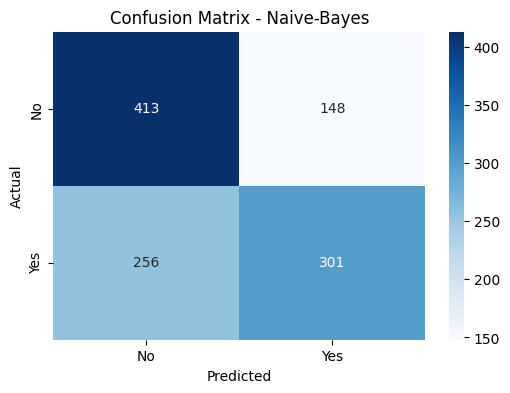

Test ROC-AUC: 0.71
Train ROC-AUC: 0.72



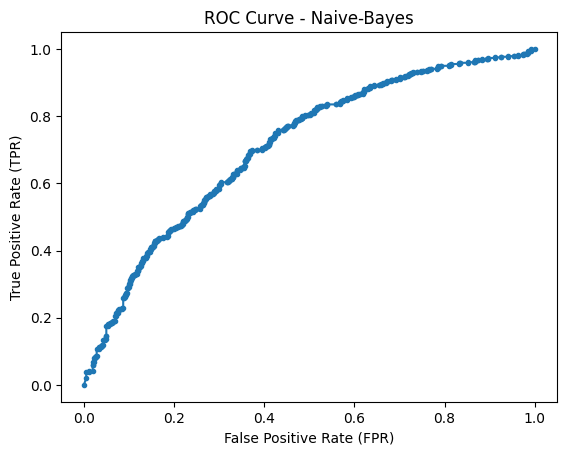

False Positive Rate (FPR): 0.01
--Evaluating Gradient Boosting--
Cross-Validation Results:
Recall: 0.81, ROC-AUC: 0.92 +- 0.007

Score: 0.84
Training Recall: 0.83
Test Recall: 0.77

Classification Report:
              precision  recall  f1-score  support
0                  0.80    0.92      0.86   561.00
1                  0.90    0.77      0.83   557.00
accuracy           0.84    0.84      0.84     0.84
macro avg          0.85    0.84      0.84  1118.00
weighted avg       0.85    0.84      0.84  1118.00


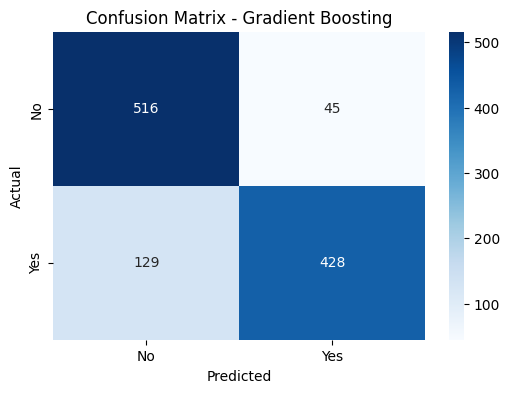

Test ROC-AUC: 0.92
Train ROC-AUC: 0.95



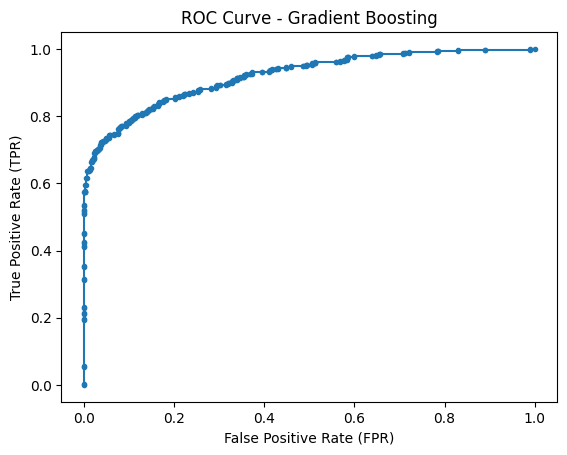

False Positive Rate (FPR): 0.00
--Evaluating Random Forest--
Cross-Validation Results:
Recall: 0.88, ROC-AUC: 0.95 +- 0.009

Score: 0.89
Training Recall: 1.00
Test Recall: 0.88

Classification Report:
              precision  recall  f1-score  support
0                  0.88    0.91      0.89   561.00
1                  0.90    0.88      0.89   557.00
accuracy           0.89    0.89      0.89     0.89
macro avg          0.89    0.89      0.89  1118.00
weighted avg       0.89    0.89      0.89  1118.00


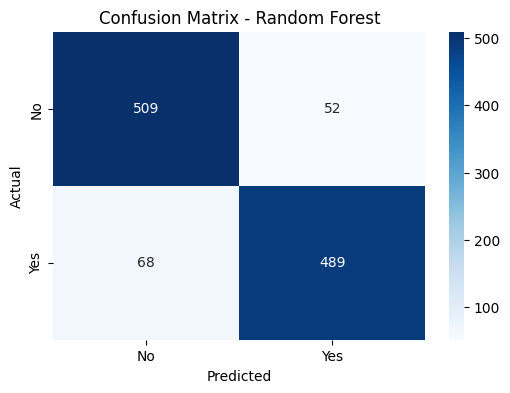

Test ROC-AUC: 0.96
Train ROC-AUC: 1.00



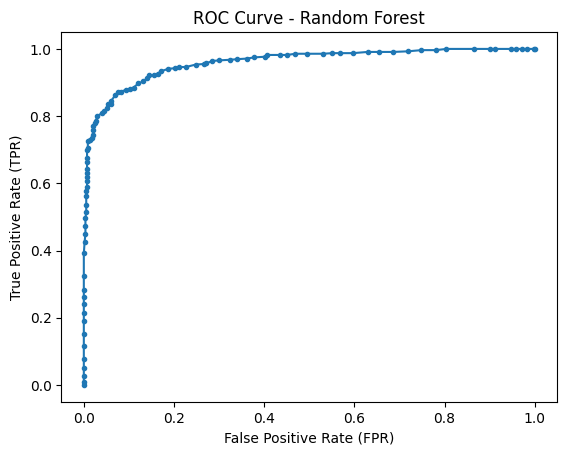

False Positive Rate (FPR): 0.00


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate

# Evaluate each model
for name, model in scale_ins_models.items():
    print(f'\n--Evaluating {name}--')
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    model.fit(X_train, y_train)
    print(f'Score: {model.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate

    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1] 
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')
